In [ ]:
# XNET 

# !pip -q install transformers datasets evaluate scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Libraries loaded for XNET approach.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
Libraries loaded for XNET approach.


In [ ]:
# load dataset and build cross-encoder input

train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

# 🔥 Key difference: structured input for XNet
def build_xnet_input(row):
    src = safe_text(row["text_src"])
    tgt = safe_text(row["text_tgt"])

    return f"Source: {src} [SEP] Edited: {tgt}"

train_df["input_text"] = train_df.apply(build_xnet_input, axis=1)
val_df["input_text"] = val_df.apply(build_xnet_input, axis=1)
test_df["input_text"] = test_df.apply(build_xnet_input, axis=1)

# label mapping
labels = train_df["label"].unique()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

train_df["label_id"] = train_df["label"].map(label2id)
val_df["label_id"] = val_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nSample XNET input:")
print(train_df["input_text"].iloc[0])

print("\nLabel mapping:")
print(label2id)

Train shape: (7478, 10)
Validation shape: (1776, 10)
Test shape: (2312, 10)

Sample XNET input:
Source: For MBTI, users were able to provide multiple texts, we report unique users in parentheses. [SEP] Edited: 

Label mapping:
{'Fact/Evidence': 0, 'Grammar': 1, 'Clarity': 2, 'Claim': 3, 'Other': 4}


In [ ]:
# convert to HuggingFace datasets

from datasets import Dataset

train_xnet = Dataset.from_pandas(train_df[["input_text", "label_id"]])
val_xnet = Dataset.from_pandas(val_df[["input_text", "label_id"]])
test_xnet = Dataset.from_pandas(test_df[["input_text", "label_id"]])

print("Train dataset:", train_xnet)
print("Validation dataset:", val_xnet)
print("Test dataset:", test_xnet)

Train dataset: Dataset({
    features: ['input_text', 'label_id'],
    num_rows: 7478
})
Validation dataset: Dataset({
    features: ['input_text', 'label_id'],
    num_rows: 1776
})
Test dataset: Dataset({
    features: ['input_text', 'label_id'],
    num_rows: 2312
})


In [ ]:
#  load tokenizer and model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

xnet_model_name = "distilbert-base-uncased"

xnet_tokenizer = AutoTokenizer.from_pretrained(xnet_model_name)

xnet_model = AutoModelForSequenceClassification.from_pretrained(
    xnet_model_name,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

print("XNET model loaded:", xnet_model_name)
print("Number of labels:", len(label2id))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XNET model loaded: distilbert-base-uncased
Number of labels: 5


In [ ]:
# tokenize data

max_length = 128

def tokenize_xnet(example):
    return xnet_tokenizer(
        example["input_text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

train_xnet_tokenized = train_xnet.map(tokenize_xnet, batched=True)
val_xnet_tokenized = val_xnet.map(tokenize_xnet, batched=True)
test_xnet_tokenized = test_xnet.map(tokenize_xnet, batched=True)

print("Tokenization completed.")
print(train_xnet_tokenized[0])

Map:   0%|          | 0/7478 [00:00<?, ? examples/s]

Map:   0%|          | 0/1776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2312 [00:00<?, ? examples/s]

Tokenization completed.
{'input_text': 'Source: For MBTI, users were able to provide multiple texts, we report unique users in parentheses. [SEP] Edited: ', 'label_id': 0, 'input_ids': [101, 3120, 1024, 2005, 16914, 3775, 1010, 5198, 2020, 2583, 2000, 3073, 3674, 6981, 1010, 2057, 3189, 4310, 5198, 1999, 27393, 1012, 102, 5493, 1024, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
#  set format for training

train_xnet_tokenized = train_xnet_tokenized.rename_column("label_id", "labels")
val_xnet_tokenized = val_xnet_tokenized.rename_column("label_id", "labels")
test_xnet_tokenized = test_xnet_tokenized.rename_column("label_id", "labels")

columns = ["input_ids", "attention_mask", "labels"]

train_xnet_tokenized.set_format(type="torch", columns=columns)
val_xnet_tokenized.set_format(type="torch", columns=columns)
test_xnet_tokenized.set_format(type="torch", columns=columns)

print("XNET dataset ready.")
print(train_xnet_tokenized[0])

XNET dataset ready.
{'labels': tensor(0), 'input_ids': tensor([  101,  3120,  1024,  2005, 16914,  3775,  1010,  5198,  2020,  2583,
         2000,  3073,  3674,  6981,  1010,  2057,  3189,  4310,  5198,  1999,
        27393,  1012,   102,  5493,  1024,   102,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
         

In [ ]:
# metrics

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_xnet_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("XNET metrics ready.")

XNET metrics ready.


In [ ]:
# training

import torch
from transformers import TrainingArguments, Trainer

xnet_training_args = TrainingArguments(
    output_dir="./xnet_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

xnet_trainer = Trainer(
    model=xnet_model,
    args=xnet_training_args,
    train_dataset=train_xnet_tokenized,
    eval_dataset=val_xnet_tokenized,
    compute_metrics=compute_xnet_metrics
)

xnet_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.864591,0.730696,0.681869,0.682493,0.681869,0.677137
2,0.578206,0.684892,0.725788,0.733120,0.725788,0.726616
3,0.449616,0.698289,0.735923,0.735085,0.735923,0.735100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1404, training_loss=0.6308045672555255, metrics={'train_runtime': 16536.3414, 'train_samples_per_second': 1.357, 'train_steps_per_second': 0.085, 'total_flos': 742983153384960.0, 'train_loss': 0.6308045672555255, 'epoch': 3.0})

In [ ]:
# evaluate on test set

xnet_test_results = xnet_trainer.evaluate(test_xnet_tokenized)
print(xnet_test_results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.6878330707550049, 'eval_accuracy': 0.7417820069204152, 'eval_precision': 0.7389504023196765, 'eval_recall': 0.7417820069204152, 'eval_f1': 0.7378838090021319, 'eval_runtime': 463.2229, 'eval_samples_per_second': 4.991, 'eval_steps_per_second': 0.313, 'epoch': 3.0}


In [ ]:
# predictions

xnet_pred_output = xnet_trainer.predict(test_xnet_tokenized)

print("Prediction completed.")
print("Shape:", xnet_pred_output.predictions.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Prediction completed.
Shape: (2312, 5)


In [ ]:
# convert predictions

import numpy as np

xnet_predictions = np.argmax(xnet_pred_output.predictions, axis=1)
xnet_true_labels = xnet_pred_output.label_ids

xnet_pred_names = [id2label[i] for i in xnet_predictions]
xnet_true_names = [id2label[i] for i in xnet_true_labels]

print("Sample predictions:")
for i in range(5):
    print("Pred:", xnet_pred_names[i], "| True:", xnet_true_names[i])

Sample predictions:
Pred: Fact/Evidence | True: Fact/Evidence
Pred: Fact/Evidence | True: Fact/Evidence
Pred: Fact/Evidence | True: Claim
Pred: Fact/Evidence | True: Claim
Pred: Claim | True: Claim


In [ ]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(
    xnet_true_names,
    xnet_pred_names,
    labels=list(label2id.keys()),
    zero_division=0
))

               precision    recall  f1-score   support

Fact/Evidence       0.80      0.87      0.84      1044
      Grammar       0.64      0.70      0.67       356
      Clarity       0.65      0.56      0.60       520
        Claim       0.76      0.65      0.70       325
        Other       0.91      0.78      0.84        67

     accuracy                           0.74      2312
    macro avg       0.75      0.71      0.73      2312
 weighted avg       0.74      0.74      0.74      2312



               Fact/Evidence  Grammar  Clarity  Claim  Other
Fact/Evidence            913       26       62     42      1
Grammar                   38      250       63      3      2
Clarity                   99      109      289     21      2
Claim                     83        0       31    211      0
Other                      7        5        3      0     52


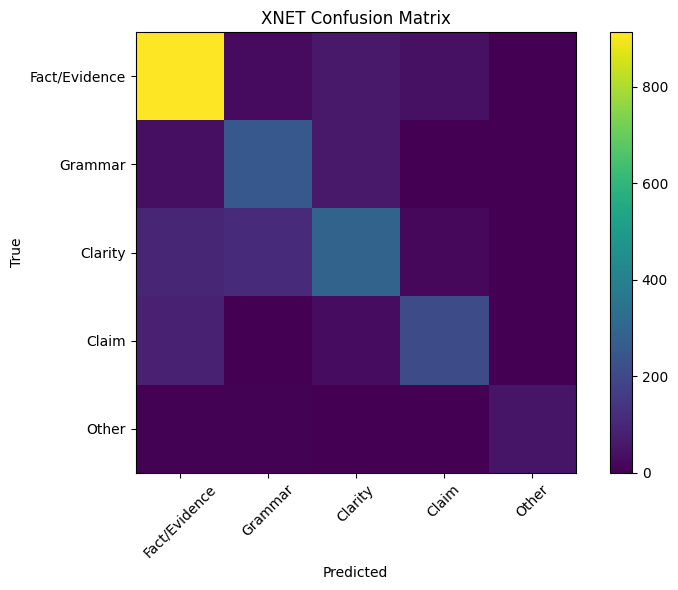

In [ ]:
#  confusion matrix

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

label_list = list(label2id.keys())

cm = confusion_matrix(xnet_true_names, xnet_pred_names, labels=label_list)

cm_df = pd.DataFrame(cm, index=label_list, columns=label_list)
print(cm_df)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("XNET Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_list)), label_list, rotation=45)
plt.yticks(range(len(label_list)), label_list)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# save model

from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/xnet_model"

xnet_trainer.save_model(save_path)
xnet_tokenizer.save_pretrained(save_path)

print("Model saved at:", save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved at: /content/drive/MyDrive/xnet_model
